![](https://drek4537l1klr.cloudfront.net/raschka/Figures/5-1.png)  
这节课主要讲述如何做预训练，这里面主要包括三部分：预训练迭代框架，模型评估方法，加载openai已经训练好的参数。

#### 5.1 Evaluating generative text models 
在上节课，咱们构建了大模型，那么接下来一个问题是如何评估模型质量好坏呢，大模型产生新的文字，如何评估新的文字是关键点。在训练过程中，我们将计算训练和验证损失（training and validation losses）.  
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/5-2.png)


##### 5.1.1 Using GPT to generate text
这里主要是快速回顾下上节课的内容，创建一个GPT模型

In [1]:
import torch
import torch.nn as nn

In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,#词典的单词个数
    "context_length":256,#支持的上下文长度为1024
    "emb_dim": 768,# 嵌入式向量长度
    "n_heads":12,# 多注意力头的个数
    "n_layers":12,# transformer block的个数
    "drop_rate":0.1, # 这里也可能设置为0，当代大模型一般也设置为0
    "qkv_bias":False
}

In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self,d_in,d_out,context_length,dropout,num_heads,qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_key = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_value = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.out_proj = nn.Linear(d_out,d_out)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length,context_length),
                       diagonal=1)
        )
    def forward(self,x):
        b,num_tokens,d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # 将keys,queries,values转化为多头的模式
        keys = keys.view(b,num_tokens,self.num_heads,self.head_dim)
        queries = queries.view(b,num_tokens,self.num_heads,self.head_dim)
        values = values.view(b,num_tokens,self.num_heads,self.head_dim)

        keys = keys.transpose(1,2)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)

        # 这里注意keys的转置，因为第0维是批次
        attn_scores = queries @ keys.transpose(2,3)
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens,:num_tokens],-torch.inf
        )
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5,dim=-1
        )
        attn_weights = self.dropout(attn_weights)
        context_vec = (attn_weights @ values).transpose(1,2)
        # contiguous方法是将张量的数据在内存中是连续的，不然view方法就会报错
        context_vec = context_vec.contiguous().view(
            b,num_tokens,self.d_out
        )
        context_vec = self.out_proj(context_vec)
        return context_vec


In [4]:
# an implementation of the GELU activation function
# pytorch也提供了GELU方法，nn.GELU()
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x):
        return 0.5 * x * (1+torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x+0.044715  * torch.pow(x,3))
        ))

In [5]:
class FeedForward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"],4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"],cfg["emb_dim"])
        )
    def forward(self,x):
        return self.layers(x)

In [6]:
class FeedForward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"],4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"],cfg["emb_dim"])
        )
    def forward(self,x):
        return self.layers(x)

In [7]:
# 将上面的代码封装进PyTorch module里，方便后面使用
class LayerNorm(nn.Module):
    def __init__(self,emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    def forward(self,x):
        mean = x.mean(dim=-1,keepdim=True)
        var = x.var(dim=-1,keepdim=True,unbiased=False)
        norm_x = (x-mean)/torch.sqrt(var+self.eps)
        return self.scale * norm_x + self.shift

In [8]:
class TransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out = cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])
    
    def forward(self,x):
        # 先经过多头注意力机制层
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = shortcut + x

        # 经过前馈网络层
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = shortcut + x

        return x

In [9]:
class GPTModel(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"],cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"],cfg["vocab_size"],bias=False
        )

    def forward(self,in_idx):
        batch_size,seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len,device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)

        x = self.trf_blocks(x)
        
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [10]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

这里和上一节课不一样的地方是，context length调小了，从1024调小到256，目的是可以让训练在个人笔记本上进行。
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/5-3.png)  
我们借用上节课的代码，将text转为token id，然后将token id 转化为text

In [11]:
def generate_text_simple(model,idx,max_new_tokens,context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:,-context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:,-1,:]
        probas = torch.softmax(logits,dim=-1)
        idx_next = torch.argmax(probas,dim=-1,keepdim=True)
        idx = torch.cat((idx,idx_next),dim=1)
    return idx

In [12]:
import tiktoken

def text_to_token_ids(text,tokenizer):
    encoded = tokenizer.encode(text,allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model = model,
    idx=text_to_token_ids(start_context,tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M['context_length']
)
print("output text:\n",token_ids_to_text(token_ids,tokenizer))

output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


##### 5.1.2 Calculating the text generation loss

![](https://drek4537l1klr.cloudfront.net/raschka/Figures/5-4.png)

In [13]:
#接下来我们使用两个输入文本做例子，来演示如何评估输出结果的质量
#“every effort moves” and "I really like"
inputs = torch.tensor([[16833,3626,6100],
                       [40,1107,588]])

In [14]:
targets = torch.tensor([[3626,6100,345],# "effort moves you"
                       [1107,588,11311]]) # "really like chocolate"

从上面可以看出，targets就是inputs的左移一位的结果。

In [15]:
with torch.no_grad():
    logits = model(inputs)
probas = torch.softmax(logits,dim=-1)
print(probas.shape)

torch.Size([2, 3, 50257])


In [16]:
token_ids = torch.argmax(probas,dim=-1,keepdim=True)
print(token_ids)

tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [17]:
print(f"Targets batch 1:{token_ids_to_text(targets[0],tokenizer)}")
print(f"Outputs batch 1:{token_ids_to_text(token_ids[0][1].unsqueeze(0),tokenizer)}")
print(f"Outputs batch 1:{token_ids_to_text(token_ids[0][2].unsqueeze(0),tokenizer)}")
print(f"Outputs batch 1:{token_ids_to_text(token_ids[0].flatten(),tokenizer)}")

Targets batch 1: effort moves you
Outputs batch 1: he
Outputs batch 1:Netflix
Outputs batch 1: Armed heNetflix


In [18]:
print(token_ids[0].flatten()[1].unsqueeze(0))
print(token_ids[0][1].squeeze(0))
print(token_ids[0].flatten().squeeze(0))

tensor([339])
tensor(339)
tensor([16657,   339, 42826])


可以看到生成的文本和目标文本差异非常大，因为模型还没有被训练。接下来我们开始评估生成的文本质量，这个也是深度学习中损失函数的核心点，也是参数更新的核心。  
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/5-5.png)  
评估方法的核心是评估生成的文本离目标文本有“多远”。  
模型训练的目标是增加与正确目标 token ID 对应的索引位置上的 softmax 概率，如图所示。这个 softmax 概率也用于我们接下来将实现的评估指标中，以数值化评估模型生成的输出：正确位置上的概率越高，模型的表现越好。
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/5-6.png)  
图 5.6 展示了一个紧凑的7 token 词汇表的 softmax 概率，以便将所有内容都放入一张图中。这意味着初始的随机值将围绕 1/7 左右，即大约 0.14。然而，我们用于 GPT-2 模型的词汇表有 50,257 个 token，因此大多数初始概率将围绕 0.00002（1/50,257）左右。

In [19]:
text_idx = 0
target_probas_1 = probas[text_idx,[0,1,2],targets[text_idx]]
print(target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx,[0,1,2],targets[text_idx]]
print(target_probas_2)

tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])
tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


训练大型语言模型（LLM）的目标是最大化正确token的似然概率，这涉及提高其相对于其他token的概率。通过这种方式，我们确保LLM能够一致地选择目标token——本质上是句子中的下一个词——作为其生成的下一个token。  
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/5-7.png)


In [20]:
log_probas = torch.log(torch.cat((target_probas_1,target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [21]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


在深度学习训练过程中，是通过参数的更新不断的将avg_log_probas逼近0，一般情况是将avg_log_probas先转为正数，然后逐步减小逼近0

In [22]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


以上这些操作被称为交叉墒损失，pytorch已经内置了方法，cross_entropy.

In [23]:
print("Logits shape:",logits.shape)
print("Targets shape:",targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


 PyTorch 中，cross_entropy损失函数要求输入张量在计算损失之前进行适当的形状调整，特别是需要将batch维度和类别维度结合起来

In [24]:
logits_flat = logits.flatten(0,1)
targets_flat = targets.flatten()
print("Flattened logits:",logits_flat.shape)
print("Flattened targets:",targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [25]:
loss = nn.functional.cross_entropy(logits_flat,targets_flat)
print(loss)

tensor(10.7940)


困惑度（Perplexity） 是自然语言处理（NLP）中常用的一个评估指标，用于衡量语言模型的性能。与原始的损失值相比，困惑度通常被认为更直观，因为它可以解释为模型在每个步骤中对生成下一个 token 的不确定性程度。以下是对困惑度的详细解释：困惑度是交叉熵损失的指数形式，公式为：  
Perplexity = ${e^{Cross Entropy Loss}}$
 
其中，交叉熵损失（Cross Entropy Loss）是模型对正确 token 的预测概率的对数的平均值。  
2. 困惑度的直观意义  
困惑度可以理解为 模型在每个步骤中需要猜测的等效词汇量。具体来说：  
困惑度越低，表示模型对生成下一个 token 的不确定性越小，性能越好。  
困惑度越高，表示模型对生成下一个 token 的不确定性越大，性能越差。  
例如：
如果困惑度为 10，表示模型平均需要在 10 个 token 中进行猜测。
如果困惑度为 100，表示模型平均需要在 100 个 token 中进行猜测。  
3. 困惑度与词汇量的关系
在给定的例子中，词汇量为 48,725，这意味着模型在生成下一个 token 时，理论上需要在 48,725 个 token 中进行选择。困惑度可以反映模型对这些 token 的不确定性程度：

如果困惑度接近 48,725，表示模型几乎完全不确定如何选择下一个 token。
如果困惑度远小于 48,725，表示模型能够有效地缩小选择范围，表现出较强的预测能力。

##### 5.1.3 Calculating the training and validation set losses
在训练之前，咱们首先需要准备好训练和验证数据集，然后咱们计算训练集和验证集的交叉墒。  
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/5-8.png)


In [26]:
file_path = "the-verdict.txt"
with open(file_path,"r",encoding="utf-8") as file:
    text_data = file.read()

In [27]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:",total_characters)
print("Tokens:",total_tokens)

Characters: 20479
Tokens: 5145


![](https://drek4537l1klr.cloudfront.net/raschka/Figures/5-9.png)  
我们正在使用大小一样的块来训练模型，以简化流程并提高效率。然而，在实际应用中，使用可变长度的输入来训练大型语言模型（LLM）也可能是有益的，因为这有助于 LLM 在应用时更好地泛化到不同类型的输入。

In [28]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [29]:
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
    def __init__(self,txt,tokenizer,max_length,stride):
        self.input_ids = []
        self.target_ids = []
        
        token_ids = tokenizer.encode(txt)
        for i in range(0,len(token_ids)-max_length,stride):
            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i+1:i+max_length+1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, index):
        return self.input_ids[index], self.target_ids[index]

In [30]:
# 创建Dataloader
def create_dataloader_v1(txt,batch_size=4,max_length=256,stride=128,shuffle=True,
                         drop_last=True,num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt,tokenizer,max_length,stride)
    dataloader = DataLoader(dataset,
                            batch_size=batch_size,
                            shuffle=shuffle,
                            drop_last=drop_last,
                            num_workers=num_workers)
    return dataloader

In [31]:
torch.manual_seed(123)
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [32]:
#查看刚才创建的数据集是否正确
print("Train loader")
for x, y in train_loader:
    print(x.shape, y.shape)
    

print("\nValidation loader")
for x, y in val_loader:
    print(x.shape, y.shape)
    print(x,y)

Train loader
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader
torch.Size([2, 256]) torch.Size([2, 256])
tensor([[  518,     6, 14707,   588,   257,  2156,   286,  4116,    13,   679,
          1422,   470, 10505,   263,    11,   345,  1833,    11,  3595,   520,
          5493,   438,   258,   655,  3830,   612, 12703,  4964,    11,   290,
           319,   465, 11914,    11,   832,   262, 12768, 21213,    11,   314,
          3947,   284,  3285,   262,  1808,    25,   705,  8491,   345,  1654,
           345,   760,   810,   345,   821,  2406,   503,  8348,   198,   198,
             1,  1532,   314,   714,   423, 13055,   326,  1986,    11,   

接下来咱们准备计算交叉墒损失函数

In [33]:
def calc_loss_batch(input_batch,target_batch,model,device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0,1),target_batch.flatten()
    )
    return loss

上面损失函数是针对一个批次的，真正做训练时候，是针对整个数据集计算损失的，这样训练效率会更高

In [34]:
def calc_loss_loader(data_loader,model,device,num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches,len(data_loader))
    
    for i,(input_batch,target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch,target_batch,model,device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches
    

默认情况下，calc_loss_loader 函数会遍历给定数据加载器（data loader）中的所有批次（batches），将每个批次的损失累加到 total_loss 变量中，然后计算并对所有批次的损失取平均。此外，我们也可以通过指定num_batches 参数来限制使用的批次数量，从而在模型训练期间加速评估过程。

为什么要对损失取平均？  
- 累加损失（total_loss）是所有批次损失的总和，但这个值的大小会受到批次数量和数据量的影响。  
- 为了得到一个标准化的损失值（即每个样本的平均损失），我们需要将累加损失除以总批次数量。
  
这样做的目的是：  
- 使损失值与批次大小无关，便于比较不同数据集或不同训练阶段的模型性能。  
- 使损失值具有明确的物理意义（即每个样本的平均误差）。  

为什么要限制批次数量（num_batches）？  
- 在模型训练过程中，评估整个数据集的损失可能会非常耗时，尤其是当数据集很大时。  
- 通过限制 num_batches，可以只计算部分批次的损失，从而加速评估过程。  
- 这种方法在训练过程中非常有用，因为训练时的评估通常只需要一个近似的损失值，而不需要完全精确的结果。  

接下来咱们开始计算训练集和验证集的损失值

In [43]:
#获取GPU的device
device_name = "cpu"
if torch.cuda.is_available():
    device_name="cuda"
elif torch.backends.mps.is_available():
    device_name="mps"
else:
    device_name="cpu"
#device_name = "cpu"
device = torch.device(device_name)
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader,model,device)
    val_loss = calc_loss_loader(val_loader,model,device)
print("Training loss:",train_loss)
print("Validation loss:",val_loss)

Training loss: 0.030952391111188464
Validation loss: 7.014489650726318


上面产生的损失值还比较大，因为目前还没有开始训练，训练的价值就是将损失值变小，产生的next token效果就会更好  
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/5-10.png)  
接下来咱们开始实现第四步LLM的训练函数

#### 2.Training an LLM
接下来实现咱们自己的GPTModel，一开始咱们一个最为直接的training loop来保持代码简洁和可读性
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/5-11.png)  
在 PyTorch 中，训练深度神经网络的典型训练循环（training loop）包含多个步骤，通常需要遍历训练集中的所有批次（batches）并重复多个轮次（epochs）。在每次循环中，我们会计算每个训练批次的损失（loss），以确定损失梯度（loss gradients），然后利用这些梯度更新模型权重，从而使训练集的损失最小化。

In [36]:
# 先实现评估模型的方法
def evaluate_model(model,train_loader,val_loader,device,eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader,model,device,eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader,model,device,eval_iter
        )
    model.train()
    return train_loss,val_loss

In [37]:
def generate_and_print_sample(model,tokenizer,device,start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context,tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model,idx=encoded,
            max_new_tokens=50,context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids,tokenizer)
    print(decoded_text.replace("\n"," "))
    model.train()

In [38]:
# 实现简单的训练模型
def train_model_simple(model,train_loader,val_loader,
                       optimizer,device,num_epoches,
                       eval_freq,eval_iter,start_context,tokenizer):
    train_losses,val_losses,track_tokens_seen = [],[],[]
    tokens_seen,global_step = 0,-1

    for epoch in range(num_epoches):
        model.train()
        for input_batch,target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch,target_batch,model,device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss,val_loss = evaluate_model(
                    model,train_loader,val_loader,device,eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1}(Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}")
                
        generate_and_print_sample(
            model,tokenizer,device,start_context
        )
    return train_losses,val_losses,track_tokens_seen

In [44]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),lr=0.0004,weight_decay=0.1
)
num_epochs = 20
train_losses, val_losses, tokens_seen = train_model_simple(
    model,train_loader,val_loader,optimizer,device,
    num_epochs,eval_freq=5,eval_iter=5,
    start_context="Every effort moves you",tokenizer=tokenizer
)

Ep 1(Step 000000): Train loss 9.929, Val loss 10.031
Ep 1(Step 000005): Train loss 8.108, Val loss 8.379
Every effort moves you,,,,,,,,,,,,,,.                                   
Ep 2(Step 000010): Train loss 6.660, Val loss 7.075
Ep 2(Step 000015): Train loss 6.070, Val loss 6.608
Every effort moves you, the,, and,,,,,,,,,,,,,,,,,,,,,,,, the,, the,,,,,,,, the,, and,,,,,
Ep 3(Step 000020): Train loss 5.603, Val loss 6.496
Ep 3(Step 000025): Train loss 5.446, Val loss 6.378
Every effort moves you, and, and the of the of the to the of the.                                    
Ep 4(Step 000030): Train loss 4.959, Val loss 6.283


这里一共迭代了175次，我第一次训练时候发生了异常，训练损失值在中间反而增大了，并没有逐步下降。  
第二次训练时候，训练损失值逐步下降，下降到很小的值，但验证集损失值下降到6就不再下降。  
这里我把device模式改为cpu,发现训练效率变慢，但稳定性提升，并且很快就达到了稳定态

20 36


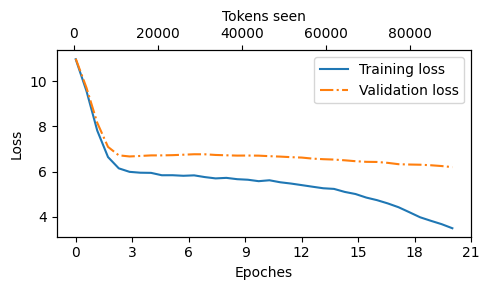

In [40]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen,tokens_seen,train_losses,val_losses):
    fig,ax1 = plt.subplots(figsize=(5,3))
    ax1.plot(epochs_seen,train_losses,label="Training loss")
    ax1.plot(
        epochs_seen,val_losses,linestyle="-.",label="Validation loss"
    )
    ax1.set_xlabel("Epoches")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen,train_losses,alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()
epochs_tensor = torch.linspace(0,num_epochs,len(train_losses))
print(num_epochs,len(train_losses))
plot_losses(epochs_tensor,tokens_seen,train_losses,val_losses)